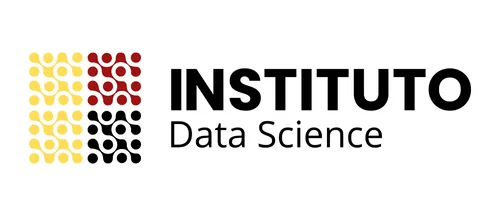 https://institutodatascience.org/

# Aprendizaje Profundo - Clase - Vinos

Este código tiene como objetivo aplicar DL para la clasificación de vinos en dos categorías de calidad (baja o alta calidad) utilizando el conjunto de datos proporcionado.

En el contexto del aprendizaje profundo, **los "embeddings"** son representaciones vectoriales de alta dimensión que capturan las relaciones y semántica entre objetos, palabras, o entidades en un espacio vectorial. Estos vectores densos son aprendidos por el modelo durante el entrenamiento y permiten expresar similitudes y relaciones semánticas de manera más efectiva que las representaciones dispersas o one-hot.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset


In [ ]:
df = pd.read_csv("/content/class_7_wine_dataset_v2.csv")

In [ ]:
df['type'].unique()

array(['white', 'red'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            6497 non-null   int64  
 1   type                  6497 non-null   object 
 2   fixed acidity         6487 non-null   float64
 3   volatile acidity      6489 non-null   float64
 4   citric acid           6494 non-null   float64
 5   residual sugar        6495 non-null   float64
 6   chlorides             6495 non-null   float64
 7   free sulfur dioxide   6497 non-null   float64
 8   total sulfur dioxide  6497 non-null   float64
 9   density               6497 non-null   float64
 10  pH                    6488 non-null   float64
 11  sulphates             6493 non-null   float64
 12  alcohol               6497 non-null   float64
 13  quality               6497 non-null   int64  
 14  vendor_id             6497 non-null   int64  
dtypes: float64(11), int64

In [ ]:
# Type es tipo categórica, transformamos con One Hot Encoding
type_dummies = pd.get_dummies(df['type'], prefix="type")

# Convertir las columnas generadas a uint8
type_dummies = type_dummies.astype('uint8')

# Ver el resultado
type_dummies.head()


,type_red,type_white
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [ ]:
df.head()

,Unnamed: 0,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,vendor_id
0,0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,369
1,1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,361
2,2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,354
3,3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,325
4,4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,375


In [ ]:
df = pd.concat([df,type_dummies], axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            6497 non-null   int64  
 1   type                  6497 non-null   object 
 2   fixed acidity         6487 non-null   float64
 3   volatile acidity      6489 non-null   float64
 4   citric acid           6494 non-null   float64
 5   residual sugar        6495 non-null   float64
 6   chlorides             6495 non-null   float64
 7   free sulfur dioxide   6497 non-null   float64
 8   total sulfur dioxide  6497 non-null   float64
 9   density               6497 non-null   float64
 10  pH                    6488 non-null   float64
 11  sulphates             6493 non-null   float64
 12  alcohol               6497 non-null   float64
 13  quality               6497 non-null   int64  
 14  vendor_id             6497 non-null   int64  
 15  type_red             

In [ ]:
# Transformamos el problema en clasificación binaria
df["quality_label"] = df["quality"].apply(lambda q:0 if q<=6 else 1)

In [ ]:
# Como tenemos pocos nan, borramos las filas donde hay nan y trabajamos con un dataset completo
ds = df[df.isna().sum(axis = 1) == 0]

In [ ]:
# Guardo vendor_id para modelo con embeddings
vendor_id = ds['vendor_id']
# Recordar que debo borrar del dataset de entrada mi columna de salida!
x = ds.drop(['Unnamed: 0','type','vendor_id','quality','quality_label'], axis=1)
y = ds['quality_label']

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6463 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6463 non-null   float64
 1   volatile acidity      6463 non-null   float64
 2   citric acid           6463 non-null   float64
 3   residual sugar        6463 non-null   float64
 4   chlorides             6463 non-null   float64
 5   free sulfur dioxide   6463 non-null   float64
 6   total sulfur dioxide  6463 non-null   float64
 7   density               6463 non-null   float64
 8   pH                    6463 non-null   float64
 9   sulphates             6463 non-null   float64
 10  alcohol               6463 non-null   float64
 11  type_red              6463 non-null   uint8  
 12  type_white            6463 non-null   uint8  
dtypes: float64(11), uint8(2)
memory usage: 618.5 KB


In [ ]:
# Normalizacion
x = x.to_numpy()
y = y.to_numpy()
x_norm = (x - np.min(x, axis=0)) / (np.max(x, axis=0 ) - np.min(x, axis=0))

In [ ]:
# Divido el dataset
idx = np.random.permutation(x_norm.shape[0])
train_idx = idx[0:int(0.85*len(idx))]
valid_idx = idx[int(0.85*len(idx)):]

train_x = x_norm[train_idx]
train_y = y[train_idx]
valid_x = x_norm[valid_idx]
valid_y = y[valid_idx]

n_train = train_x.shape[0]
n_valid = valid_x.shape[0]

## Pytorch

### Modelo sin embeddings

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn import metrics

In [ ]:
# Pytorch necesita de una clase de dataset que extienda de torch.utils.data.Dataset
# Esta clase dataset debe sobreescribir los métodos init, len y getitem
class MyDataset(Dataset):

  #__init__ guarda el dataset en una variable de clase
  def __init__(self, x, y):
    self.x = x
    self.y = y

  # __len__ define el comportamiento de la función len() sobre el objeto
  def __len__(self):
    return self.x.shape[0]

  # __getitem__ define el comportamiento de los []
  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

In [ ]:
# Creo el dataset de entrenamiento
train_ds = MyDataset(train_x, train_y)
# Creo el dataset de validación
valid_ds = MyDataset(valid_x, valid_y)

In [ ]:
# Se crean dos DataLoader que entregan los datos en lotes de 64 ejemplos.
train_dataloader = DataLoader(train_ds, batch_size=64, shuffle=True)   # Para entrenamiento: baraja el dataset cada época.
valid_dataloader = DataLoader(valid_ds, batch_size=64)                 # Para validación: recorre los datos en orden fijo.

In [ ]:
# Arquitectura
class NNet(torch.nn.Module):                    # define una red neuronal personalizada heredando de nn.Module

  def __init__(self):
    # Defino la arquitectura de la red
    super().__init__()                         # inicializa la clase base nn.Module
    self.linear_1 = torch.nn.Linear(13, 200)   # capa lineal: 13 entradas -> 200 neuronas
    self.relu_1 = torch.nn.ReLU()              # primera activación ReLU
    self.linear_2 = torch.nn.Linear(200, 100)  # capa lineal intermedia: 200 -> 100
    self.relu_2 = torch.nn.ReLU()              # segunda activación ReLU
    self.output = torch.nn.Linear(100, 1)      # capa final: 100 -> salida escalar

  def forward(self, x):
    # Defino el cálculo del paso forward
    x = self.linear_1(x)                       # aplica la primera capa lineal
    x = self.relu_1(x)                         # activa con ReLU
    x = self.linear_2(x)                       # segunda capa lineal
    x = self.relu_2(x)                         # segunda activación ReLU
    x = self.output(x)                         # capa de salida
    return x                                   # devuelve la predicción


In [ ]:
# Instanciamos la red
nnet = NNet()

In [ ]:
# Función de pérdida y optimizador
loss_function = torch.nn.BCEWithLogitsLoss(reduction='sum')
optimizer = torch.optim.Adam(nnet.parameters(), lr=0.01)

In [ ]:
device = "cpu"
if torch.cuda.is_available():
  device = "cuda:0"

device

'cuda:0'

In [ ]:
# Copio la red neuronal al dispositivo donde entrene la red neuronal
nnet = nnet.to(device)

In [ ]:
# Algoritmo Mini-batch

# cantidad de epochs
epochs = 100                                     # número total de épocas de entrenamiento

train_loss_by_epoch=[]
valid_loss_by_epoch=[]                           # listas para registrar la pérdida en train/valid por época

# Doble loop algoritmo Mini-Batch
for epoch in range(epochs):                      # itera sobre cada época del entrenamiento

  ############################################
  ## Entrenamiento
  ############################################
  nnet.train(True)                               # coloca la red en modo entrenamiento (activa dropout/bn si existieran)

  epoch_loss = 0
  epoch_y_hat = []
  epoch_y = []                                   # contenedores para acumular pérdidas y predicciones de la época

  for i, data in enumerate(train_dataloader):    # recorre cada mini-batch del conjunto de entrenamiento
    # Obtengo los datos del batch de entrenamiento
    x_batch, y_batch = data
    # Copio el batch al dispositivo donde entreno la red neuronal
    x_batch = x_batch.to(device).float()
    y_batch = y_batch.to(device).float().reshape(-1, 1)

    # Paso forward
    # Limpio optimizer para empezar un nuevo cálculo de gradiente
    optimizer.zero_grad()                        # reinicia gradientes antes del backward
    nnet_output = nnet(x_batch)                  # calcula logits pasando el batch por la red
    y_batch_hat = torch.sigmoid(nnet_output)     # aplica sigmoide para obtener probabilidades (binarias)

    # Calculo el loss
    loss = loss_function(nnet_output, y_batch)   # evalúa la función de pérdida con logits vs etiquetas

    # Backpropagation
    loss.backward()                              # propaga gradientes hacia atrás

    # Actualizar los parámetros
    optimizer.step()                             # actualiza parámetros con el optimizador

    # Almaceno los valores reales y mis predicciones para cálcular las métricas
    epoch_y += list(y_batch.detach().cpu().numpy())
    epoch_y_hat += list(y_batch_hat.detach().cpu().numpy())
    # Acumulo la loss del batch
    epoch_loss = epoch_loss + loss.item()

  # Calculo la media de la loss
  epoch_loss = epoch_loss / n_train              # promedio de pérdida sobre muestras de entrenamiento
  # Almaceno la loss de la epoch para graficar
  train_loss_by_epoch.append(epoch_loss)
  # Cálculo la métrica de la epoch
  accuracy = metrics.accuracy_score(epoch_y, [j >= 0.5 for j in epoch_y_hat])  # accuracy binaria usando umbral 0.5

  ############################################
  ## Validación
  ############################################
  
  # Setup Usa epochs=100 para repetir entrenamiento/validación;
  # arreglos train_loss_by_epoch y valid_loss_by_epoch guardan pérdidas promedio en cada época:67.
  
  # Desactivo el cálculo de gradiente para validación
  nnet.train(False)                              # pone la red en modo evaluación (desactiva dropout/bn)

  valid_epoch_loss = 0
  valid_epoch_y_hat = []
  valid_epoch_y = []                             # contenedores para pérdidas y predicciones de validación

  for i, data in enumerate(valid_dataloader):    # recorre cada mini-batch de validación
    # Obtengo los datos del batch de validación
    x_batch, y_batch = data
    # Copio el batch al dispositivo donde entreno la red neuronal
    x_batch = x_batch.to(device).float()
    y_batch = y_batch.to(device).float().reshape(-1, 1)

    # Paso forward
    nnet_output = nnet(x_batch)                  # calcula logits del batch de validación
    y_batch_hat = torch.sigmoid(nnet_output)     # obtiene probabilidades con sigmoide

    # Calculo el loss
    loss = loss_function(nnet_output, y_batch)   # pérdida sobre el batch de validación

    # En validación no hago backpropagation!!

    # Almaceno los valores reales y mis predicciones para cálcular las métricas
    valid_epoch_y += list(y_batch.detach().cpu().numpy())
    valid_epoch_y_hat += list(y_batch_hat.detach().cpu().numpy())
    # Acumulo la loss del batch
    valid_epoch_loss = valid_epoch_loss + loss.item()

  # Calculo la media de la loss
  valid_epoch_loss = valid_epoch_loss / n_valid  # promedio de pérdida en validación
  # Almaceno la loss de la epoch para graficar
  valid_loss_by_epoch.append(valid_epoch_loss)
  # Cálculo la métrica de la epoch
  valid_accuracy = metrics.accuracy_score(valid_epoch_y, [j >= 0.5 for j in valid_epoch_y_hat])

  ############################################
  ## Impresión de resultados por epoch
  ############################################
  print(
    f" Epoch {epoch} | "
    f"Train/Valid loss: {epoch_loss:.3f} / {valid_epoch_loss:.3f} | "
    f"Train/Valid accuracy: {accuracy:.3f} / {valid_accuracy:.3f}"
  )                                              # muestra pérdidas y accuracy de train/valid por época

 Epoch 0 | Train/Valid loss: 0.432 / 0.383 | Train/Valid accuracy: 0.809 / 0.826
 Epoch 1 | Train/Valid loss: 0.407 / 0.395 | Train/Valid accuracy: 0.814 / 0.824
 Epoch 2 | Train/Valid loss: 0.406 / 0.387 | Train/Valid accuracy: 0.817 / 0.818
 Epoch 3 | Train/Valid loss: 0.398 / 0.372 | Train/Valid accuracy: 0.818 / 0.830
 Epoch 4 | Train/Valid loss: 0.389 / 0.366 | Train/Valid accuracy: 0.824 / 0.826
 Epoch 5 | Train/Valid loss: 0.384 / 0.365 | Train/Valid accuracy: 0.824 / 0.832
 Epoch 6 | Train/Valid loss: 0.381 / 0.362 | Train/Valid accuracy: 0.824 / 0.821
 Epoch 7 | Train/Valid loss: 0.374 / 0.381 | Train/Valid accuracy: 0.827 / 0.803
 Epoch 8 | Train/Valid loss: 0.372 / 0.360 | Train/Valid accuracy: 0.825 / 0.828
 Epoch 9 | Train/Valid loss: 0.374 / 0.383 | Train/Valid accuracy: 0.823 / 0.829
 Epoch 10 | Train/Valid loss: 0.373 / 0.375 | Train/Valid accuracy: 0.825 / 0.822
 Epoch 11 | Train/Valid loss: 0.367 / 0.375 | Train/Valid accuracy: 0.830 / 0.820
 Epoch 12 | Train/Valid lo

In [ ]:
print(" Epoch {} | Train/Valid loss: {:.3f} / {:.3f} | Train/Valid accuracy: {:.3f} / {:.3f}".format(
    epoch, epoch_loss, valid_epoch_loss, accuracy, valid_accuracy))


 Epoch 99 | Train/Valid loss: 0.320 / 0.375 | Train/Valid accuracy: 0.844 / 0.831


Text(0, 0.5, 'BCE')

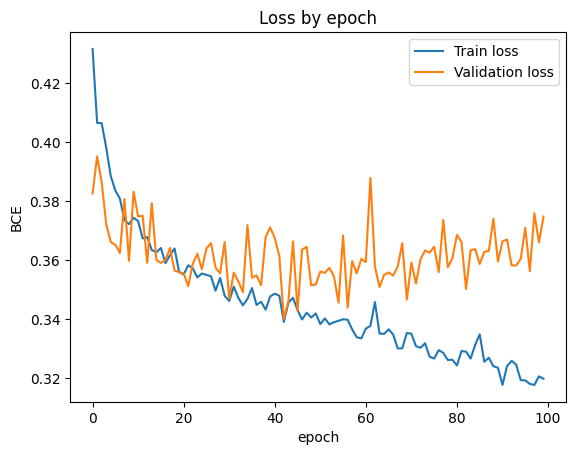

In [ ]:
# Grafica loss por epoch
fig, ax1= plt.subplots(1,1)
ax1.plot(train_loss_by_epoch, label="Train loss")
ax1.plot(valid_loss_by_epoch, label="Validation loss")
ax1.legend()
ax1.set_title("Loss by epoch")
ax1.set_xlabel("epoch")
ax1.set_ylabel("BCE")

### Modelo con Embeddings

In [ ]:
# No puedo utilizar OHE con vendor_id
len(vendor_id.unique())

500

In [ ]:
# Los vendor id no son consecutivos
vendor_id.unique()

array([369, 361, 354, 325, 375, 380, 312, 301, 355, 290, 210, 260, 421,
       248, 416, 383, 277, 586, 413, 559, 234, 317, 318, 353, 305, 470,
       381, 347, 396, 243, 232, 200, 358, 256, 374, 384, 357, 393, 462,
       143, 252, 329, 257, 389, 469, 459, 335, 334, 359, 306, 323, 339,
       209, 379, 373, 203, 464, 276, 233, 288, 230, 331, 536, 254, 401,
       478, 247, 348, 321, 206, 316, 268, 365, 322, 261, 367, 215, 438,
       496, 482, 399, 417, 270, 214, 241, 263, 274, 326, 286, 275, 279,
       132, 385, 307, 218, 223, 352, 308, 471, 461, 269, 449, 265, 228,
       445, 299, 345, 320, 313, 190, 466, 300, 409, 372, 398, 227, 440,
       573, 578, 486, 244, 212, 294, 497, 262, 392, 150, 196, 239, 194,
       250, 351, 287, 245, 272, 506, 180, 390, 253, 282, 222, 235, 264,
       266, 292, 157, 137, 415, 324, 240, 258, 350, 284, 340, 207, 182,
       314, 338, 433, 201, 432, 311, 437, 441, 439, 105,  72,  80, 360,
       403, 114, 273, 395, 309, 291, 249, 140, 518, 562, 152, 22

In [ ]:
# Transformo vendor id a indices (idx) consecutivos para utilizar embeddings
vendor_id_to_idx = {value:i for i,value in enumerate(vendor_id.unique())}

In [ ]:
# Vector de vendor_idx en el dataset
vendor_idx = np.array([vendor_id_to_idx[value] for value in vendor_id])
vendor_idx

array([  0,   1,   2, ..., 206, 124,  46])

In [ ]:
# Divido el vector vendor_idx en entrenamiento y validación
vendor_idx_train = vendor_idx[train_idx]
vendor_idx_valid = vendor_idx[valid_idx]

In [ ]:
# Clase Dataset de Pytorch con embeddings
class MyDatasetWithEmbddings(Dataset):

  def __init__(self, x, vendor_idx, y):
    self.x = x
    self.vendor_idx = vendor_idx
    self.y = y

  def __len__(self):
    return self.x.shape[0]

  def __getitem__(self, idx):
    return self.x[idx], self.vendor_idx[idx], self.y[idx]

In [ ]:
train_ds_embeddings = MyDatasetWithEmbddings(train_x, vendor_idx_train, train_y)
valid_ds_embeddings = MyDatasetWithEmbddings(valid_x, vendor_idx_valid, valid_y)

In [ ]:
train_dataloader_emb = DataLoader(train_ds_embeddings, batch_size =64, shuffle= True)
valid_dataloader_emb = DataLoader(valid_ds_embeddings, batch_size=64)

**Regla General:** Una regla empírica es que la dimensión de los embeddings puede estar relacionada con el logaritmo del número de categorías. En este caso, para 500 categorías (vendor_id), el logaritmo base 2 es aproximadamente 9, por lo que una dimensión de 8 es razonable.

**Prueba y Error:** A menudo, la dimensión de los embeddings se determina mediante prueba y error, evaluando el desempeño del modelo con diferentes dimensiones.

In [ ]:
# Arquitectura con embeddings
class NNetWithEmbeddings(torch.nn.Module):

  def __init__(self):
    # Constructor de la clase
    super().__init__()

    # Capa de embeddings
    self.embeddings = torch.nn.Embedding(num_embeddings=500, embedding_dim=8)

    # Capa lineal 1
    self.linear_1 = torch.nn.Linear(in_features=13+8, out_features=200, bias=True)

    # Función de activación ReLU 1
    self.relu_1 = torch.nn.ReLU()

    # Capa lineal 2
    self.linear_2 = torch.nn.Linear(in_features=200, out_features=100, bias=True)

    # Función de activación ReLU 2
    self.relu_2 = torch.nn.ReLU()

    # Capa de salida
    self.output = torch.nn.Linear(in_features=100, out_features=1, bias=True)

  def forward(self, x, vendor_idx):
    # Método forward para realizar el paso hacia adelante (forward pass)

    # Obtener las salidas de embeddings para el índice del vendedor
    embeddings_outputs = self.embeddings(vendor_idx)

    # Concatenar las características originales con las salidas de embeddings
    x = torch.cat([x, embeddings_outputs], dim=1)

    # Capa lineal 1
    x = self.linear_1(x)

    # Función de activación ReLU 1
    x = self.relu_1(x)

    # Capa lineal 2
    x = self.linear_2(x)

    # Función de activación ReLU 2
    x = self.relu_2(x)

    # Capa de salida
    x = self.output(x)

    # Devolver la salida
    return x


In [ ]:
# Crear una instancia del modelo con embeddings
nnnetWithEmbeddings = NNetWithEmbeddings()

# Mover el modelo a la GPU si está disponible, de lo contrario, quedarse en la CPU
nnnetWithEmbeddings = nnnetWithEmbeddings.to(device)


En este bloque, se utiliza la función de pérdida BCEWithLogitsLoss que combina la función sigmoid con la función de pérdida de entropía cruzada binaria (BCE). El parámetro reduction='sum' indica que se sumarán todas las pérdidas en lugar de tomar el promedio.

Para el optimizador Adam, se utiliza un learning rate (tasa de aprendizaje) de 0.001 y se agrega regularización L2 (weight decay) con un valor de 0.01 para controlar el sobreajuste. La regularización L2 penaliza los pesos grandes en el modelo, ayudando a prevenir el sobreajuste al introducir un término de penalización en la función de pérdida proporcional al cuadrado de los pesos del modelo.

In [ ]:
# Definir la función de pérdida (Binary Cross Entropy with Logits Loss)
loss_function = torch.nn.BCEWithLogitsLoss(reduction='sum')

# Definir el optimizador Adam con learning rate (lr) de 0.001 y regularización L2 (weight_decay) de 0.01
optimizer = torch.optim.Adam(nnnetWithEmbeddings.parameters(), lr=0.001, weight_decay=0.01)


In [ ]:
# Mini-Batch

# cantidad de epochs
epochs = 100

train_loss_by_epoch=[]
valid_loss_by_epoch=[]

# Doble loop algoritmo Mini-Batch
for epoch in range(epochs):

  ############################################
  ## Entrenamiento
  ############################################
  nnnetWithEmbeddings.train(True)

  epoch_loss = 0
  epoch_y_hat = []
  epoch_y = []

  for i,data in enumerate(train_dataloader_emb):
    # Obtengo los datos del batch de entrenamiento
    x_batch, embed_batch, y_batch = data
    # Copio el batch al dispositivo donde entreno la red neuronal
    x_batch = x_batch.to(device).float()
    embed_batch = embed_batch.to(device).int()
    y_batch = y_batch.to(device).float().reshape(-1, 1)

    # Paso forward
    # Limpio optimizer para empezar un nuevo cálculo de gradiente
    optimizer.zero_grad()
    nnet_output = nnnetWithEmbeddings(x_batch, embed_batch)
    y_batch_hat = torch.sigmoid(nnet_output)

    # Calculo el loss
    loss = loss_function(nnet_output, y_batch)

    # Backpropagation
    loss.backward()

    # Actualizar los parámetros
    optimizer.step()

    # Almaceno los valores reales y mis predicciones para cálcular las métricas
    epoch_y += list(y_batch.detach().cpu().numpy())
    epoch_y_hat += list(y_batch_hat.detach().cpu().numpy())
    # Acumulo la loss del batch
    epoch_loss = epoch_loss + loss.item()

  # Calculo la media de la loss
  epoch_loss = epoch_loss / n_train
  # Almaceno la loss de la epoch para graficar
  train_loss_by_epoch.append(epoch_loss)
  # Cálculo la métrica de la epoch
  accuracy = metrics.accuracy_score(epoch_y, [j>=0.5 for j in epoch_y_hat])

  ############################################
  ## Validación
  ############################################
  # Desactivo el cálculo de gradiente para validación
  nnnetWithEmbeddings.train(False)

  valid_epoch_loss = 0
  valid_epoch_y_hat = []
  valid_epoch_y = []

  for i,data in enumerate(valid_dataloader_emb):
    # Obtengo los datos del batch de validación
    x_batch, embed_batch, y_batch = data
    # Copio el batch al dispositivo donde entreno la red neuronal
    x_batch = x_batch.to(device).float()
    embed_batch = embed_batch.to(device).int()
    y_batch = y_batch.to(device).float().reshape(-1, 1)

    # Paso forward
    nnet_output = nnnetWithEmbeddings(x_batch, embed_batch)
    y_batch_hat = torch.sigmoid(nnet_output)

    # Calculo el loss
    loss = loss_function(nnet_output, y_batch)

    # En validación no hago backpropagation!!

    # Almaceno los valores reales y mis predicciones para cálcular las métricas
    valid_epoch_y += list(y_batch.detach().cpu().numpy())
    valid_epoch_y_hat += list(y_batch_hat.detach().cpu().numpy())
    # Acumulo la loss del batch
    valid_epoch_loss = valid_epoch_loss + loss.item()

  # Calculo la media de la loss
  valid_epoch_loss = valid_epoch_loss / n_valid
  # Almaceno la loss de la epoch para graficar
  valid_loss_by_epoch.append(valid_epoch_loss)
  # Cálculo la métrica de la epoch
  valid_accuracy = metrics.accuracy_score(valid_epoch_y, [j>=0.5 for j in valid_epoch_y_hat])

  ############################################
  ## Impresión de resultados por epoch
  ############################################
  print(f" Epoch {epoch} | " \
        f"Train/Valid loss: {epoch_loss:.3f} / {valid_epoch_loss:.3f} | " \
        f"Train/Valid accuracy: {accuracy:.3f} / {valid_accuracy:.3f}")

 Epoch 0 | Train/Valid loss: 0.468 / 0.418 | Train/Valid accuracy: 0.803 / 0.812
 Epoch 1 | Train/Valid loss: 0.370 / 0.328 | Train/Valid accuracy: 0.843 / 0.879
 Epoch 2 | Train/Valid loss: 0.279 / 0.260 | Train/Valid accuracy: 0.892 / 0.905
 Epoch 3 | Train/Valid loss: 0.208 / 0.198 | Train/Valid accuracy: 0.926 / 0.934
 Epoch 4 | Train/Valid loss: 0.148 / 0.160 | Train/Valid accuracy: 0.952 / 0.943
 Epoch 5 | Train/Valid loss: 0.102 / 0.120 | Train/Valid accuracy: 0.969 / 0.961
 Epoch 6 | Train/Valid loss: 0.073 / 0.101 | Train/Valid accuracy: 0.979 / 0.966
 Epoch 7 | Train/Valid loss: 0.052 / 0.094 | Train/Valid accuracy: 0.987 / 0.971
 Epoch 8 | Train/Valid loss: 0.040 / 0.084 | Train/Valid accuracy: 0.991 / 0.973
 Epoch 9 | Train/Valid loss: 0.032 / 0.072 | Train/Valid accuracy: 0.992 / 0.979
 Epoch 10 | Train/Valid loss: 0.026 / 0.080 | Train/Valid accuracy: 0.994 / 0.973
 Epoch 11 | Train/Valid loss: 0.020 / 0.057 | Train/Valid accuracy: 0.996 / 0.977
 Epoch 12 | Train/Valid lo

In [ ]:
#Modelo con Embeddings
print(f" Epoch {epoch} | " \
      f"Train/Valid loss: {epoch_loss:.3f} / {valid_epoch_loss:.3f} | " \
      f"Train/Valid accuracy: {accuracy:.3f} / {valid_accuracy:.3f}")



 Epoch 99 | Train/Valid loss: 0.000 / 0.014 | Train/Valid accuracy: 1.000 / 0.993


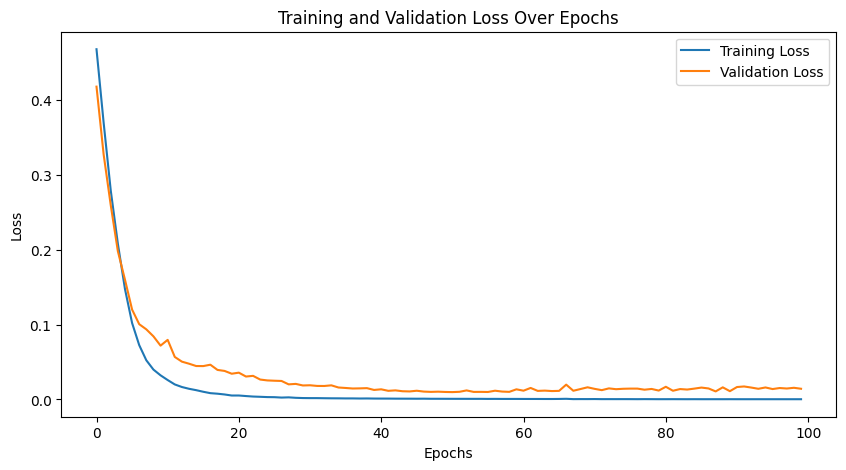

In [ ]:
# Graficar las curvas de pérdida
plt.figure(figsize=(10, 5))
plt.plot(train_loss_by_epoch, label='Training Loss')
plt.plot(valid_loss_by_epoch, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import torch  # Importa el paquete PyTorch
from sklearn import metrics  # Importa las métricas de sklearn para evaluación del modelo
import plotly.express as px  # Importa Plotly Express para la visualización
import pandas as pd  # Importa pandas para el manejo de datos

# Cambia el modelo a modo evaluación
nnnetWithEmbeddings.eval()

# Listas para almacenar todas las predicciones y las etiquetas reales
all_predictions = []
all_labels = []

# Desactiva el cálculo de gradientes
with torch.no_grad():
    for inputs, embed_batch, labels in valid_dataloader_emb:
        # Mueve los datos de entrada al dispositivo (CPU o GPU)
        inputs = inputs.to(device).float()
        embed_batch = embed_batch.to(device).int()
        labels = labels.to(device).float().reshape(-1, 1)

        # Obtiene las predicciones del modelo
        outputs = nnnetWithEmbeddings(inputs, embed_batch)
        probabilities = torch.sigmoid(outputs).cpu().numpy()  # Convierte las salidas a probabilidades usando la función sigmoide

        # Convierte probabilidades a etiquetas (0 o 1) usando un umbral de 0.5
        predictions = (probabilities >= 0.5).astype(int)

        # Almacena las predicciones y las etiquetas reales
        all_predictions.extend(predictions)
        all_labels.extend(labels.cpu().numpy())

# Matriz de Confusión
conf_matrix = metrics.confusion_matrix(all_labels, all_predictions)  # Calcula la matriz de confusión
conf_matrix_df = pd.DataFrame(conf_matrix, index=["Baja calidad (0)", "Alta calidad (1)"], columns=["Pred. Baja calidad (0)", "Pred. Alta calidad (1)"])  # Crea un DataFrame de pandas para la matriz de confusión con etiquetas descriptivas

# Visualizar la matriz de confusión usando Plotly Express
fig = px.imshow(conf_matrix_df, text_auto=True, color_continuous_scale='Blues', aspect='auto')  # Crea una visualización de la matriz de confusión
fig.update_layout(title="Matriz de Confusión", xaxis_title="Predicciones", yaxis_title="Etiquetas Reales")  # Configura los títulos del gráfico para claridad
fig.show()  # Muestra la visualización

# Reporte de Clasificación para métricas detalladas
class_report = metrics.classification_report(all_labels, all_predictions, target_names=["Baja calidad (0)", "Alta calidad (1)"])  # Genera un reporte detallado con precisión, recall, F1-score y soporte
print("Reporte de Clasificación:\n", class_report)  # Imprime el reporte de clasificación


Reporte de Clasificación:
                   precision    recall  f1-score   support

Baja calidad (0)       0.99      1.00      1.00       783
Alta calidad (1)       1.00      0.96      0.98       187

        accuracy                           0.99       970
       macro avg       1.00      0.98      0.99       970
    weighted avg       0.99      0.99      0.99       970



## Análisis Económico del Modelo de Clasificación de Vinos 🍷

Este modelo se utiliza en una empresa que clasifica vinos en dos categorías: alta calidad y baja calidad. A partir de la matriz de confusión y el reporte de clasificación, podemos realizar los siguientes análisis económicos:

### Costos y Beneficios:

- **Costo de Falsos Positivos (FP)**: Predicciones de alta calidad cuando en realidad son de baja calidad.
- **Costo de Falsos Negativos (FN)**: Predicciones de baja calidad cuando en realidad son de alta calidad.
- **Beneficios de Verdaderos Positivos (TP)**: Predicciones correctas de alta calidad.
- **Beneficios de Verdaderos Negativos (TN)**: Predicciones correctas de baja calidad.

### Suposiciones para el análisis económico:

- **Precio de venta del vino de alta calidad**: s50 por botella.
- **Precio de venta del vino de baja calidad**: s20 por botella.
- **Costo de producción del vino**: s10 por botella.
- **Pérdida por falsos positivos**: s30 por botella (se vende como alta calidad, pero es de baja calidad).
- **Pérdida por falsos negativos**: s20 por botella (se vende como baja calidad, pero es de alta calidad).


In [ ]:
# Definición de costos y beneficios
precio_alta_calidad = 50
precio_baja_calidad = 20
costo_produccion = 10
perdida_fp = 30  # Falsos positivos
perdida_fn = 20  # Falsos negativos

# Extracción de la matriz de confusión
tn, fp, fn, tp = conf_matrix.ravel()

# Cálculo de pérdidas y beneficios
beneficio_tp = tp * (precio_alta_calidad - costo_produccion)
beneficio_tn = tn * (precio_baja_calidad - costo_produccion)
costo_fp = fp * perdida_fp
costo_fn = fn * perdida_fn

# Cálculo del beneficio neto
beneficio_neto = beneficio_tp + beneficio_tn - costo_fp - costo_fn

# Impresión del análisis económico
print(f"Beneficio Neto: ${beneficio_neto}")


Beneficio Neto: $14890
